### Contribution Being Reproduced

In this experiment, I reproduce the **Delta TF-IDF weighting scheme** proposed in the paper *“A Study of Information Retrieval Weighting Schemes for Sentiment Analysis.”*

The paper investigates whether improved term weighting schemes from Information Retrieval can enhance sentiment classification accuracy.

The specific contribution reproduced here is the **Delta TF-IDF representation**, which modifies the traditional TF-IDF weighting by computing class-specific inverse document frequencies and taking their difference.

### Evaluation Metric

The evaluation metric used is **classification accuracy**, which is the same metric used in the experiments reported in the paper.

In [33]:
import numpy as np
import pandas as pd
import random
import re

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [34]:
def preprocess_text(text):
    """
    Simple preprocessing protocol:
    - Lowercase
    - Remove punctuation and numbers
    - Collapse whitespace
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # remove punctuation & digits
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

### Reproducibility Setup

Random seeds are fixed to ensure that the results of the experiment are reproducible.  
This ensures that dataset sampling and model training produce consistent outputs across runs.

In [35]:
df = pd.read_csv("data/imdb_toy_dataset.csv")

# Apply preprocessing
df["clean_review"] = df["review"].apply(preprocess_text)
text = df["clean_review"].values
label = df["sentiment"].values

print(f"Dataset loaded and preprocessed. Total samples: {len(df)}")

Dataset loaded and preprocessed. Total samples: 2000


### Dataset Loading

The toy dataset prepared in **Task 2.1** is loaded for the experiment.

Each document contains:
- a text review
- a binary sentiment label (positive or negative)

This dataset serves as a simplified environment to reproduce the method proposed in the paper.

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(text)

### Binary Feature Representation (Baseline)

This step converts each document into a **binary bag-of-words representation**.

For each word in the vocabulary:

- weight = 1 if the word appears in the document
- weight = 0 otherwise

Binary weighting is commonly used as a baseline in sentiment classification using Support Vector Machines.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(text)

### Standard TF-IDF Representation

This step implements the traditional **TF-IDF weighting scheme**, defined as:

w_i = tf_i × log(N / df_i)

Where:
- tf_i is the frequency of term i in the document
- df_i is the number of documents containing the term
- N is the total number of documents

TF-IDF highlights words that appear frequently in a document but rarely across the entire dataset.

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(text)

vocab_size = X_counts.shape[1]

pos_docs = X_counts[label == 1]
neg_docs = X_counts[label == 0]

df_pos = np.array((pos_docs > 0).sum(axis=0)).flatten()
df_neg = np.array((neg_docs > 0).sum(axis=0)).flatten()

N_pos = pos_docs.shape[0]
N_neg = neg_docs.shape[0]

delta_idf = np.log((N_pos * (df_neg + 1)) / ((df_pos + 1) * N_neg))

X_delta = X_counts.multiply(delta_idf)

### Delta TF-IDF Representation

This step implements the **Delta TF-IDF weighting scheme** proposed in the paper.

Unlike traditional TF-IDF, Delta TF-IDF calculates inverse document frequency separately for each class.

The weight of a term is computed as:

w_i = tf_i × log((N1 × df_i2) / (df_i1 × N2))

Where:
- df_i1 = number of documents in class 1 containing the term
- df_i2 = number of documents in class 2 containing the term
- N1 and N2 are the total documents in each class.

This weighting highlights words that appear more frequently in one sentiment class than the other.

In [39]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_delta, label, test_size=0.2, random_state=SEED
)

model = LinearSVC()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy_delta = accuracy_score(y_test, predictions)
accuracy_delta

0.885

### Training the Sentiment Classifier

A **linear Support Vector Machine (SVM)** is trained using the Delta TF-IDF feature representation.

SVM classifiers are widely used for text classification tasks and were also used in the experiments of the paper.

The trained model predicts the sentiment label of unseen documents, and the prediction accuracy is measured.

In [40]:
from sklearn.svm import LinearSVC

def train_and_eval(X):
    X_train, X_test, y_train, y_test = train_test_split(
        X, label, test_size=0.2, random_state=SEED
    )
    
    model = LinearSVC()
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    return accuracy_score(y_test, preds)

acc_binary = train_and_eval(X_binary)
acc_tfidf = train_and_eval(X_tfidf)
acc_delta = train_and_eval(X_delta)

print("Binary Accuracy:", acc_binary)
print("TF-IDF Accuracy:", acc_tfidf)
print("Delta TF-IDF Accuracy:", acc_delta)

Binary Accuracy: 0.7925
TF-IDF Accuracy: 0.845
Delta TF-IDF Accuracy: 0.885


### Result Interpretation

The experiment compares three feature representations:

| Method | Accuracy |
|------|------|
| Binary Representation | 0.7925 |
| TF-IDF Representation | 0.845 |
| Delta TF-IDF Representation | 0.885 |

The results show that **Delta TF-IDF improves sentiment classification performance compared to the baseline representations.**

This supports the claim of the paper that **class-specific weighting of terms can better capture sentiment-related words and improve classification accuracy.**

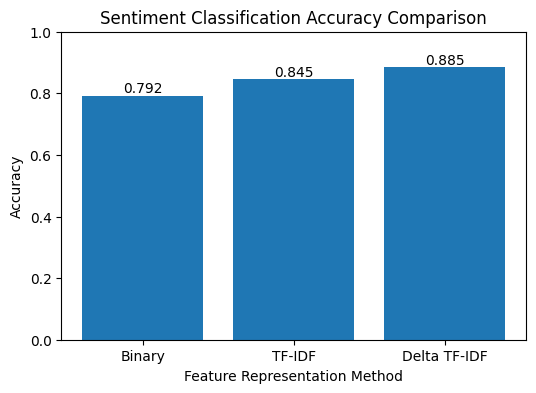

In [41]:
import matplotlib.pyplot as plt
import os

methods = ["Binary", "TF-IDF", "Delta TF-IDF"]
accuracies = [acc_binary, acc_tfidf, acc_delta]

plt.figure(figsize=(6,4))
plt.bar(methods, accuracies)

plt.title("Sentiment Classification Accuracy Comparison")
plt.xlabel("Feature Representation Method")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

# Save figure for assignment submission
os.makedirs("results", exist_ok=True)
plt.savefig("results/accuracy_comparison.png", bbox_inches="tight")

plt.show()